In [1]:
import os
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy import io

# Add workspace root to path so msca is importable
sys.path.insert(0, os.path.abspath("../../.."))
from msca import *
from msca.evaluations import evaluate_trial_average_MLP, evaluate_trial_average_Linear, evaluate_trial_average_MLP_region, evaluate_trial_average_Linear_region

# Re-import explicitly after wildcard imports to avoid namespace collisions
from sklearn.model_selection import KFold

import matplotlib.pyplot as plt


In [2]:
def load_data(dir_path, f):
    mat_file = io.loadmat(dir_path + f)
    data_array = mat_file["data"]
    mask = mat_file["mask"]
    start_idxs = mat_file["mask"]["firstTimeEachCond"][0][0].squeeze() - 1
    end_idxs = mat_file["mask"]["lastTimeEachCond"][0][0].squeeze()
    return data_array, mask, start_idxs, end_idxs


def preprocess(data_array, start_idxs, end_idxs, downsample_factor=5):
    if downsample_factor is not None:
        data_downsamp = data_array[::downsample_factor]
        start_idxs = start_idxs // downsample_factor
        end_idxs = end_idxs // downsample_factor
    else:
        data_downsamp = data_array

    data_concat = data_downsamp.T
    fr_range = np.ptp(data_concat, axis=1)[:, None]
    data_norm = data_concat / (fr_range + 5)
    data_snm_norm = data_norm - np.mean(data_norm, axis=1)[:, None]
    fit_data = np.copy(data_snm_norm.T)
    split_data = [fit_data[i:j] for i, j in zip(start_idxs, end_idxs)]
    return split_data


# Paths (relative to the notebook directory in experiments/cycling/)
fp = "./data/"


m1_data, m1_mask, m1_start_idxs, m1_end_idxs = load_data(fp, "Cousteau_interp_cycling_m1_rawRates.mat")
sma_data, sma_mask, sma_start_idxs, sma_end_idxs = load_data(fp, "Cousteau_interp_cycling_sma_rawRates.mat")

m1_preprocessed = preprocess(m1_data, m1_start_idxs, m1_end_idxs, downsample_factor=5)
sma_preprocessed = preprocess(sma_data, sma_start_idxs, sma_end_idxs, downsample_factor=5)

X = {"M1": m1_preprocessed, "SMA": sma_preprocessed}

print(f"M1:  {len(m1_preprocessed)} trials, {m1_preprocessed[0].shape[1]} neurons")
print(f"SMA: {len(sma_preprocessed)} trials, {sma_preprocessed[0].shape[1]} neurons")


M1:  20 trials, 116 neurons
SMA: 20 trials, 77 neurons


# 40, MLP

## Visualize Z when lam_region == 0.0 or lam_region == 0.5

Found 5 neuron folds
Found 15 lam_region values: [0.0, 0.1, 0.3, 0.5, 0.8, 1.0, 1.2, 1.5, 1.8, 2.0, 2.3, 2.5, 2.6, 2.8, 3.0]

=== lam_region=0.0 ===
Initialized mSCA with lam_sparse=2.5, lam_orthog=0.0, lam_region=0.0
passed lam_sparse: 2.5
passed lam_orthog: 0.0
Using region-weights = {'M1': 0.7975064363288057, 'SMA': 1.3403179544112407}
Using lam_sparse = 0.08812463819255682
Using lam_orthog = 0.0
Using lam_region = 0.0
Checkpoint training hyperparameters:
  lam_sparse  = 0.08812463819255682
  lam_orthog  = 0.0
  lam_region  = 0.0
  region_weights = {'M1': 0.7975064363288057, 'SMA': 1.3403179544112407}


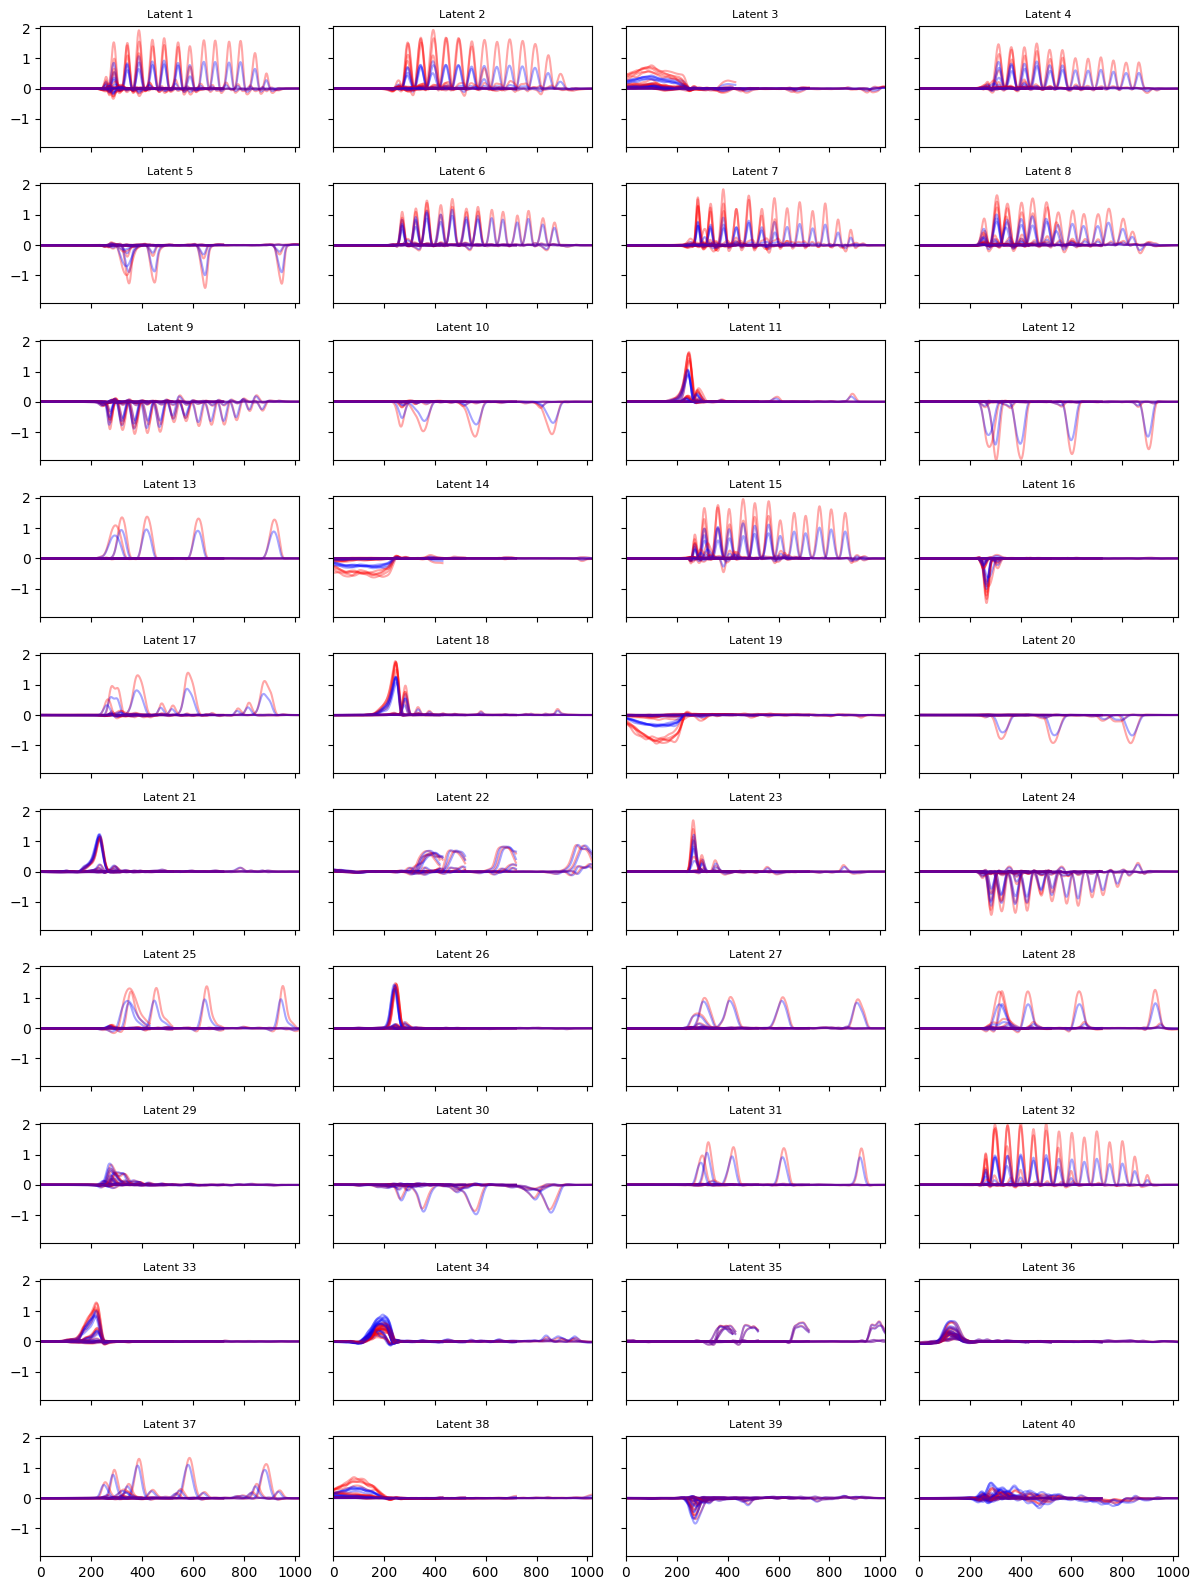

Initialized mSCA with lam_sparse=2.5, lam_orthog=0.0, lam_region=0.0
passed lam_sparse: 2.5
passed lam_orthog: 0.0
Using region-weights = {'M1': 0.7748147412125208, 'SMA': 1.4097037476845866}
Using lam_sparse = 0.09067048718693743
Using lam_orthog = 0.0
Using lam_region = 0.0
Checkpoint training hyperparameters:
  lam_sparse  = 0.09067048718693743
  lam_orthog  = 0.0
  lam_region  = 0.0
  region_weights = {'M1': 0.7748147412125208, 'SMA': 1.4097037476845866}


<Figure size 640x480 with 0 Axes>

Initialized mSCA with lam_sparse=2.5, lam_orthog=0.0, lam_region=0.0
passed lam_sparse: 2.5
passed lam_orthog: 0.0
Using region-weights = {'M1': 0.7918909087294841, 'SMA': 1.3564843663277388}
Using lam_sparse = 0.08719028411721379
Using lam_orthog = 0.0
Using lam_region = 0.0
Checkpoint training hyperparameters:
  lam_sparse  = 0.08719028411721379
  lam_orthog  = 0.0
  lam_region  = 0.0
  region_weights = {'M1': 0.7918909087294841, 'SMA': 1.3564843663277388}


<Figure size 640x480 with 0 Axes>

Initialized mSCA with lam_sparse=2.5, lam_orthog=0.0, lam_region=0.0
passed lam_sparse: 2.5
passed lam_orthog: 0.0
Using region-weights = {'M1': 0.7823761702463815, 'SMA': 1.3853438297639196}
Using lam_sparse = 0.08776341774532091
Using lam_orthog = 0.0
Using lam_region = 0.0
Checkpoint training hyperparameters:
  lam_sparse  = 0.08776341774532091
  lam_orthog  = 0.0
  lam_region  = 0.0
  region_weights = {'M1': 0.7823761702463815, 'SMA': 1.3853438297639196}


<Figure size 640x480 with 0 Axes>

Initialized mSCA with lam_sparse=2.5, lam_orthog=0.0, lam_region=0.0
passed lam_sparse: 2.5
passed lam_orthog: 0.0
Using region-weights = {'M1': 0.813251157638652, 'SMA': 1.2980816475972463}
Using lam_sparse = 0.08664245755343558
Using lam_orthog = 0.0
Using lam_region = 0.0
Checkpoint training hyperparameters:
  lam_sparse  = 0.08664245755343558
  lam_orthog  = 0.0
  lam_region  = 0.0
  region_weights = {'M1': 0.813251157638652, 'SMA': 1.2980816475972463}


<Figure size 640x480 with 0 Axes>


=== lam_region=0.1 ===
Initialized mSCA with lam_sparse=2.5, lam_orthog=0.0, lam_region=0.1
passed lam_sparse: 2.5
passed lam_orthog: 0.0
Using region-weights = {'M1': 0.7975064363288057, 'SMA': 1.3403179544112407}
Using lam_sparse = 0.08812463819255682
Using lam_orthog = 0.0
Using lam_region = 114.70920941483405
Checkpoint training hyperparameters:
  lam_sparse  = 0.08812463819255682
  lam_orthog  = 0.0
  lam_region  = 114.70920941483405
  region_weights = {'M1': 0.7975064363288057, 'SMA': 1.3403179544112407}
Initialized mSCA with lam_sparse=2.5, lam_orthog=0.0, lam_region=0.1
passed lam_sparse: 2.5
passed lam_orthog: 0.0
Using region-weights = {'M1': 0.7748147412125208, 'SMA': 1.4097037476845866}
Using lam_sparse = 0.09067048718693743
Using lam_orthog = 0.0
Using lam_region = 116.40300711453726
Checkpoint training hyperparameters:
  lam_sparse  = 0.09067048718693743
  lam_orthog  = 0.0
  lam_region  = 116.40300711453726
  region_weights = {'M1': 0.7748147412125208, 'SMA': 1.40970374

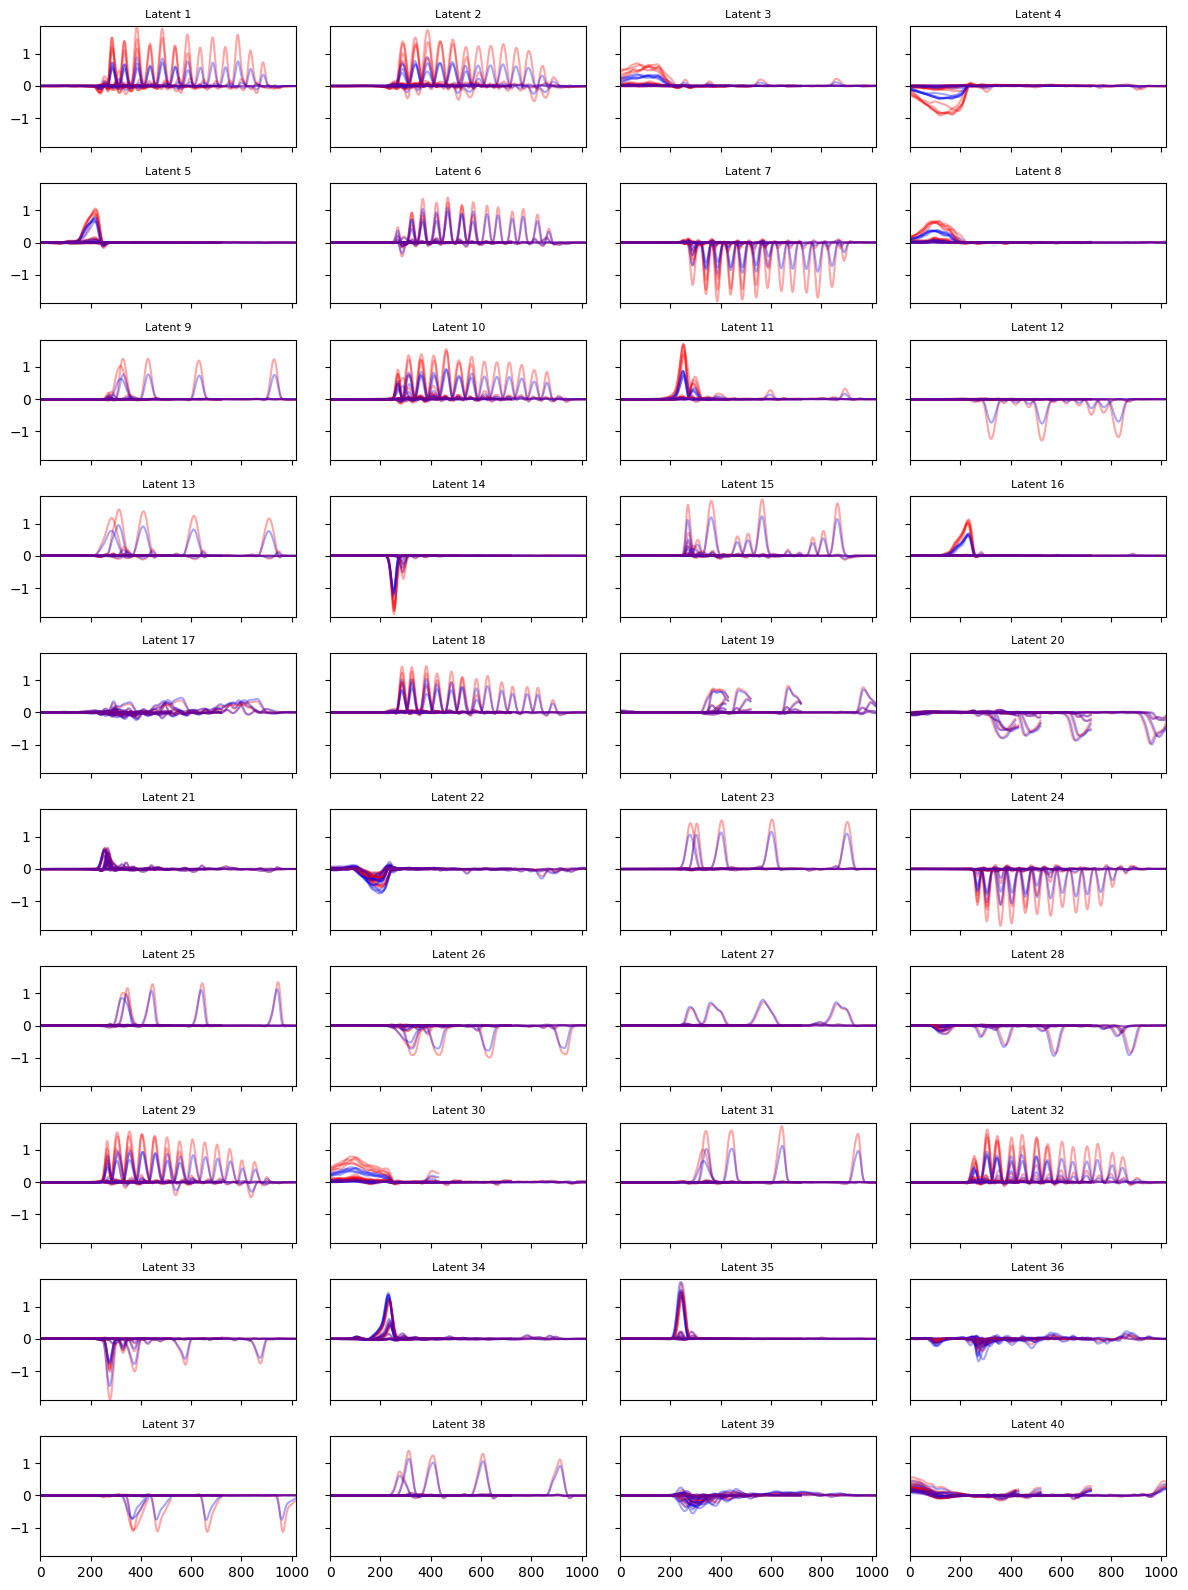

Initialized mSCA with lam_sparse=2.5, lam_orthog=0.0, lam_region=0.5
passed lam_sparse: 2.5
passed lam_orthog: 0.0
Using region-weights = {'M1': 0.7748147412125208, 'SMA': 1.4097037476845866}
Using lam_sparse = 0.09067048718693743
Using lam_orthog = 0.0
Using lam_region = 582.0150355726863
Checkpoint training hyperparameters:
  lam_sparse  = 0.09067048718693743
  lam_orthog  = 0.0
  lam_region  = 582.0150355726863
  region_weights = {'M1': 0.7748147412125208, 'SMA': 1.4097037476845866}


<Figure size 640x480 with 0 Axes>

Initialized mSCA with lam_sparse=2.5, lam_orthog=0.0, lam_region=0.5
passed lam_sparse: 2.5
passed lam_orthog: 0.0
Using region-weights = {'M1': 0.7918909087294841, 'SMA': 1.3564843663277388}
Using lam_sparse = 0.08719028411721379
Using lam_orthog = 0.0
Using lam_region = 573.804704878403
Checkpoint training hyperparameters:
  lam_sparse  = 0.08719028411721379
  lam_orthog  = 0.0
  lam_region  = 573.804704878403
  region_weights = {'M1': 0.7918909087294841, 'SMA': 1.3564843663277388}


<Figure size 640x480 with 0 Axes>

Initialized mSCA with lam_sparse=2.5, lam_orthog=0.0, lam_region=0.5
passed lam_sparse: 2.5
passed lam_orthog: 0.0
Using region-weights = {'M1': 0.7823761702463815, 'SMA': 1.3853438297639196}
Using lam_sparse = 0.08776341774532091
Using lam_orthog = 0.0
Using lam_region = 569.4433082149475
Checkpoint training hyperparameters:
  lam_sparse  = 0.08776341774532091
  lam_orthog  = 0.0
  lam_region  = 569.4433082149475
  region_weights = {'M1': 0.7823761702463815, 'SMA': 1.3853438297639196}


<Figure size 640x480 with 0 Axes>

Initialized mSCA with lam_sparse=2.5, lam_orthog=0.0, lam_region=0.5
passed lam_sparse: 2.5
passed lam_orthog: 0.0
Using region-weights = {'M1': 0.813251157638652, 'SMA': 1.2980816475972463}
Using lam_sparse = 0.08664245755343558
Using lam_orthog = 0.0
Using lam_region = 539.42617015507
Checkpoint training hyperparameters:
  lam_sparse  = 0.08664245755343558
  lam_orthog  = 0.0
  lam_region  = 539.42617015507
  region_weights = {'M1': 0.813251157638652, 'SMA': 1.2980816475972463}


<Figure size 640x480 with 0 Axes>


=== lam_region=0.8 ===
Initialized mSCA with lam_sparse=2.5, lam_orthog=0.0, lam_region=0.8
passed lam_sparse: 2.5
passed lam_orthog: 0.0
Using region-weights = {'M1': 0.7975064363288057, 'SMA': 1.3403179544112407}
Using lam_sparse = 0.08812463819255682
Using lam_orthog = 0.0
Using lam_region = 917.6736753186724
Checkpoint training hyperparameters:
  lam_sparse  = 0.08812463819255682
  lam_orthog  = 0.0
  lam_region  = 917.6736753186724
  region_weights = {'M1': 0.7975064363288057, 'SMA': 1.3403179544112407}
Initialized mSCA with lam_sparse=2.5, lam_orthog=0.0, lam_region=0.8
passed lam_sparse: 2.5
passed lam_orthog: 0.0
Using region-weights = {'M1': 0.7748147412125208, 'SMA': 1.4097037476845866}
Using lam_sparse = 0.09067048718693743
Using lam_orthog = 0.0
Using lam_region = 931.2240569162981
Checkpoint training hyperparameters:
  lam_sparse  = 0.09067048718693743
  lam_orthog  = 0.0
  lam_region  = 931.2240569162981
  region_weights = {'M1': 0.7748147412125208, 'SMA': 1.409703747684

In [ ]:
experiment_root = "./results/bi-cross-validation-Cousteau-nonlinear-nonlinear-lamsparse-2.5-components-40/"
n_components = 40

# Load shared neuron split indices
train_idxs = torch.load(os.path.join(experiment_root, "n_train_splits.pt"), weights_only=False)
test_idxs  = torch.load(os.path.join(experiment_root, "n_test_splits.pt"),  weights_only=False)

k0 = list(train_idxs.keys())[0]
n_folds = len(train_idxs[k0])
print(f"Found {n_folds} neuron folds")

# Discover all lam_region subdirectories and sort numerically
lam_dirs = []
for name in sorted(os.listdir(experiment_root)):
    path = os.path.join(experiment_root, name)
    if not (os.path.isdir(path) and name.startswith("lam_region_")):
        continue
    lam_str = name.replace("lam_region_", "").replace("p", ".")
    try:
        lam_dirs.append((float(lam_str), path))
    except ValueError:
        continue
lam_dirs.sort(key=lambda x: x[0])
print(f"Found {len(lam_dirs)} lam_region values: {[v for v, _ in lam_dirs]}")

# Accumulate R² per lam_region
results = {}   

for lam_val, model_dir in lam_dirs:
    all_scores, m1_scores, sma_scores = [], [], []
    print(f"\n=== lam_region={lam_val} ===")

    for i in range(n_folds):
        model_path = os.path.join(model_dir, f"msca_split_{i}.pt")
        if not os.path.exists(model_path):
            print(f"  [skip] missing fold {i}")
            continue

        # Build held-in / held-out neuron sets for this fold
        X_train_fold = {
            k: [trial[:, train_idxs[k][i]] for trial in v]
            for k, v in X.items()
        }
        X_val_fold = {
            k: [trial[:, test_idxs[k][i]] for trial in v]
            for k, v in X.items()
        }

        # Reconstruct model with the same config used during training
        msca_model = mSCA(
            n_components=n_components,
            linear=False,
            loss_func="Gaussian",
            lam_sparse=2.5,
            lam_orthog=0.0,
            lam_region=lam_val,
            decoder_type="nonlinear",
            decoder_hidden_size=n_components,
            decoder_activation="GeLU",
            post_hoc_epoch=-1,
            cd_rate=0.5,
            cd_mode="both",
            filter_len=41,
            init="unique",
            decoder_init_mode="pca",
        )
        msca_model.load(model_path, X_train_fold)
        if lam_val == 0.0 or lam_val == 0.5:

            if i == 0:

                Z = msca_model.transform(X_train_fold)
                n_splits=5
                T = np.arange(len(Z[list(Z.keys())[0]]))
                kf = KFold(n_splits=n_splits, shuffle=True, random_state=0)
                # visualization of Z 
                n_components = 40
                # there are 20 trails for each region
                n_trials = min(20, len(Z['M1']), len(Z['SMA']))

                # Global y-range across all plotted traces so every subplot uses the same scale
                all_vals = []
                for j in range(n_trials):
                    all_vals.append(Z['M1'][j][:, :n_components].ravel())
                    all_vals.append(Z['SMA'][j][:, :n_components].ravel())
                all_vals = np.concatenate(all_vals)
                ymin, ymax = np.min(all_vals), np.max(all_vals)

                # Global x-range across all plotted traces
                max_t = max(max(Z['M1'][j].shape[0], Z['SMA'][j].shape[0]) for j in range(n_trials))

                fig, axs = plt.subplots(10, 4, figsize=(12, 16), sharex=True, sharey=True)
                for i in range(n_components): # plot each component in its own subplot
                    ax = axs[i // 4, i % 4]
                    for j in range(n_trials): # plot 20 trails per region on the same subplot
                        ax.plot(Z['M1'][j][:, i], c='r', alpha=0.35)
                        ax.plot(Z['SMA'][j][:, i], c='b', alpha=0.35)
                    ax.set_xlim(0, max_t - 1)
                    ax.set_ylim(ymin, ymax)
                    ax.set_title(f'Latent {i + 1}', fontsize=8)

            plt.tight_layout()
            plt.show()

Found 5 neuron folds
Found 15 lam_region values: [0.0, 0.1, 0.3, 0.5, 0.8, 1.0, 1.2, 1.5, 1.8, 2.0, 2.3, 2.5, 2.6, 2.8, 3.0]

=== lam_region=0.0 ===
Initialized mSCA with lam_sparse=2.5, lam_orthog=0.0, lam_region=0.0
passed lam_sparse: 2.5
passed lam_orthog: 0.0
Using region-weights = {'M1': 0.7975064363288057, 'SMA': 1.3403179544112407}
Using lam_sparse = 0.08812463819255682
Using lam_orthog = 0.0
Using lam_region = 0.0
Checkpoint training hyperparameters:
  lam_sparse  = 0.08812463819255682
  lam_orthog  = 0.0
  lam_region  = 0.0
  region_weights = {'M1': 0.7975064363288057, 'SMA': 1.3403179544112407}
  fold 0: R²_all=0.7659  R²_M1=0.7806  R²_SMA=0.7388
Initialized mSCA with lam_sparse=2.5, lam_orthog=0.0, lam_region=0.0
passed lam_sparse: 2.5
passed lam_orthog: 0.0
Using region-weights = {'M1': 0.7748147412125208, 'SMA': 1.4097037476845866}
Using lam_sparse = 0.09067048718693743
Using lam_orthog = 0.0
Using lam_region = 0.0
Checkpoint training hyperparameters:
  lam_sparse  = 0.090

[2026-05-15 09:40:53,438] torch._dynamo.convert_frame: [WARNING] torch._dynamo hit config.cache_size_limit (8)
[2026-05-15 09:40:53,438] torch._dynamo.convert_frame: [WARNING]    function: 'forward' (/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/filters.py:124)
[2026-05-15 09:40:53,438] torch._dynamo.convert_frame: [WARNING]    last reason: ___guarded_code.valid
[2026-05-15 09:40:53,438] torch._dynamo.convert_frame: [WARNING] To log all recompilation reasons, use TORCH_LOGS="recompiles".
[2026-05-15 09:40:53,438] torch._dynamo.convert_frame: [WARNING] To diagnose recompilation issues, see https://pytorch.org/docs/master/compile/troubleshooting.html.


  fold 1: R²_all=0.7701  R²_M1=0.8128  R²_SMA=0.6808
Initialized mSCA with lam_sparse=2.5, lam_orthog=0.0, lam_region=0.0
passed lam_sparse: 2.5
passed lam_orthog: 0.0
Using region-weights = {'M1': 0.7918909087294841, 'SMA': 1.3564843663277388}
Using lam_sparse = 0.08719028411721379
Using lam_orthog = 0.0
Using lam_region = 0.0
Checkpoint training hyperparameters:
  lam_sparse  = 0.08719028411721379
  lam_orthog  = 0.0
  lam_region  = 0.0
  region_weights = {'M1': 0.7918909087294841, 'SMA': 1.3564843663277388}
  fold 2: R²_all=0.7671  R²_M1=0.7877  R²_SMA=0.7295
Initialized mSCA with lam_sparse=2.5, lam_orthog=0.0, lam_region=0.0
passed lam_sparse: 2.5
passed lam_orthog: 0.0
Using region-weights = {'M1': 0.7823761702463815, 'SMA': 1.3853438297639196}
Using lam_sparse = 0.08776341774532091
Using lam_orthog = 0.0
Using lam_region = 0.0
Checkpoint training hyperparameters:
  lam_sparse  = 0.08776341774532091
  lam_orthog  = 0.0
  lam_region  = 0.0
  region_weights = {'M1': 0.7823761702463

[2026-05-15 09:41:19,174] torch._dynamo.convert_frame: [WARNING] torch._dynamo hit config.cache_size_limit (8)
[2026-05-15 09:41:19,174] torch._dynamo.convert_frame: [WARNING]    function: '_gaussian_filter' (/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/filters.py:72)
[2026-05-15 09:41:19,174] torch._dynamo.convert_frame: [WARNING]    last reason: ___guarded_code.valid
[2026-05-15 09:41:19,174] torch._dynamo.convert_frame: [WARNING] To log all recompilation reasons, use TORCH_LOGS="recompiles".
[2026-05-15 09:41:19,174] torch._dynamo.convert_frame: [WARNING] To diagnose recompilation issues, see https://pytorch.org/docs/master/compile/troubleshooting.html.


  fold 1: R²_all=0.7656  R²_M1=0.8071  R²_SMA=0.6799
Initialized mSCA with lam_sparse=2.5, lam_orthog=0.0, lam_region=0.1
passed lam_sparse: 2.5
passed lam_orthog: 0.0
Using region-weights = {'M1': 0.7918909087294841, 'SMA': 1.3564843663277388}
Using lam_sparse = 0.08719028411721379
Using lam_orthog = 0.0
Using lam_region = 114.76094097568061
Checkpoint training hyperparameters:
  lam_sparse  = 0.08719028411721379
  lam_orthog  = 0.0
  lam_region  = 114.76094097568061
  region_weights = {'M1': 0.7918909087294841, 'SMA': 1.3564843663277388}
  fold 2: R²_all=0.7748  R²_M1=0.7934  R²_SMA=0.7404
Initialized mSCA with lam_sparse=2.5, lam_orthog=0.0, lam_region=0.1
passed lam_sparse: 2.5
passed lam_orthog: 0.0
Using region-weights = {'M1': 0.7823761702463815, 'SMA': 1.3853438297639196}
Using lam_sparse = 0.08776341774532091
Using lam_orthog = 0.0
Using lam_region = 113.88866164298949
Checkpoint training hyperparameters:
  lam_sparse  = 0.08776341774532091
  lam_orthog  = 0.0
  lam_region  = 

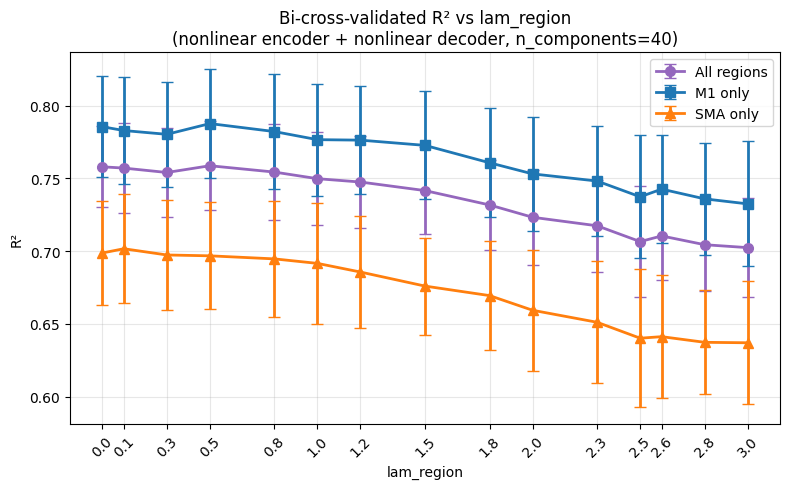


Summary:
  lam_region    R²_all     R²_M1    R²_SMA
         0.0    0.7580    0.7856    0.6988
         0.1    0.7572    0.7830    0.7017
         0.3    0.7541    0.7804    0.6974
         0.5    0.7588    0.7878    0.6968
         0.8    0.7544    0.7823    0.6947
         1.0    0.7499    0.7767    0.6916
         1.2    0.7476    0.7764    0.6857
         1.5    0.7417    0.7728    0.6760
         1.8    0.7318    0.7608    0.6695
         2.0    0.7233    0.7532    0.6594
         2.3    0.7175    0.7483    0.6511
         2.5    0.7066    0.7374    0.6402
         2.6    0.7105    0.7427    0.6412
         2.8    0.7045    0.7360    0.6373
         3.0    0.7025    0.7325    0.6370


In [ ]:
experiment_root = "./results/bi-cross-validation-Cousteau-nonlinear-nonlinear-lamsparse-2.5-components-40/"
n_components = 40

# Load shared neuron split indices
train_idxs = torch.load(os.path.join(experiment_root, "n_train_splits.pt"), weights_only=False)
test_idxs  = torch.load(os.path.join(experiment_root, "n_test_splits.pt"),  weights_only=False)

k0 = list(train_idxs.keys())[0]
n_folds = len(train_idxs[k0])
print(f"Found {n_folds} neuron folds")

# Discover all lam_region subdirectories and sort numerically
lam_dirs = []
for name in sorted(os.listdir(experiment_root)):
    path = os.path.join(experiment_root, name)
    if not (os.path.isdir(path) and name.startswith("lam_region_")):
        continue
    lam_str = name.replace("lam_region_", "").replace("p", ".")
    try:
        lam_dirs.append((float(lam_str), path))
    except ValueError:
        continue
lam_dirs.sort(key=lambda x: x[0])
print(f"Found {len(lam_dirs)} lam_region values: {[v for v, _ in lam_dirs]}")

# Accumulate R² per lam_region
results = {}   

for lam_val, model_dir in lam_dirs:
    all_scores, m1_scores, sma_scores = [], [], []
    print(f"\n=== lam_region={lam_val} ===")

    for i in range(n_folds):
        model_path = os.path.join(model_dir, f"msca_split_{i}.pt")
        if not os.path.exists(model_path):
            print(f"  [skip] missing fold {i}")
            continue

        # Build held-in / held-out neuron sets for this fold
        X_train_fold = {
            k: [trial[:, train_idxs[k][i]] for trial in v]
            for k, v in X.items()
        }
        X_val_fold = {
            k: [trial[:, test_idxs[k][i]] for trial in v]
            for k, v in X.items()
        }

        # Reconstruct model with the same config used during training
        msca_model = mSCA(
            n_components=n_components,
            linear=False,
            loss_func="Gaussian",
            lam_sparse=2.5,
            lam_orthog=0.0,
            lam_region=lam_val,
            decoder_type="nonlinear",
            decoder_hidden_size=n_components,
            decoder_activation="GeLU",
            post_hoc_epoch=-1,
            cd_rate=0.5,
            cd_mode="both",
            filter_len=41,
            init="unique",
            decoder_init_mode="pca",
        )
        msca_model.load(model_path, X_train_fold)

        # Evaluate: returns (performances_all, performances_m1, performances_sma)
        perf_all, perf_m1, perf_sma = evaluate_trial_average_MLP_region(
            msca_model, X_train_fold, X_val_fold, n_splits=5
        )
        all_scores.extend(perf_all)
        m1_scores.extend(perf_m1)
        sma_scores.extend(perf_sma)
        print(f"  fold {i}: R²_all={np.mean(perf_all):.4f}  "
              f"R²_M1={np.mean(perf_m1):.4f}  R²_SMA={np.mean(perf_sma):.4f}")

    if len(all_scores) == 0:
        print("  [warn] no valid scores, skipping.")
        continue

    results[lam_val] = {
        "all": np.array(all_scores, dtype=float),
        "m1":  np.array(m1_scores,  dtype=float),
        "sma": np.array(sma_scores,  dtype=float),
    }

print("\nEvaluation complete.")

# ── Plot ──────────────────────────────────────────────────────────────────────
lam_vals = sorted(results.keys())

mean_all = np.array([results[v]["all"].mean() for v in lam_vals])
std_all  = np.array([results[v]["all"].std()  for v in lam_vals])
mean_m1  = np.array([results[v]["m1"].mean()  for v in lam_vals])
std_m1   = np.array([results[v]["m1"].std()   for v in lam_vals])
mean_sma = np.array([results[v]["sma"].mean() for v in lam_vals])
std_sma  = np.array([results[v]["sma"].std()  for v in lam_vals])

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(lam_vals, mean_all, yerr=std_all,
            fmt="o-", color="tab:purple", linewidth=2, markersize=7, capsize=4,
            label="All regions")
ax.errorbar(lam_vals, mean_m1,  yerr=std_m1,
            fmt="s-", color="tab:blue",   linewidth=2, markersize=7, capsize=4,
            label="M1 only")
ax.errorbar(lam_vals, mean_sma, yerr=std_sma,
            fmt="^-", color="tab:orange", linewidth=2, markersize=7, capsize=4,
            label="SMA only")

ax.set_xlabel("lam_region")
ax.set_ylabel("R²")
ax.set_title("Bi-cross-validated R² vs lam_region\n"
             "(nonlinear encoder + nonlinear decoder, n_components=40)")
ax.set_xticks(lam_vals)
ax.tick_params(axis="x", rotation=45)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print("\nSummary:")
print(f"{'lam_region':>12}  {'R²_all':>8}  {'R²_M1':>8}  {'R²_SMA':>8}")
for v in lam_vals:
    print(f"{v:>12.1f}  {results[v]['all'].mean():>8.4f}  "
          f"{results[v]['m1'].mean():>8.4f}  {results[v]['sma'].mean():>8.4f}")


# 70 MLP

## Visualize Z when lam_region == 0.0 or lam_region == 0.3 or lam_region == 2.6

Found 5 neuron folds
Found 15 lam_region values: [0.0, 0.1, 0.3, 0.5, 0.8, 1.0, 1.2, 1.5, 1.8, 2.0, 2.3, 2.5, 2.6, 2.8, 3.0]

=== lam_region=0.0 ===
Initialized mSCA with lam_sparse=2.5, lam_orthog=0.0, lam_region=0.0
passed lam_sparse: 2.5
passed lam_orthog: 0.0
Using region-weights = {'M1': 0.7466287869447, 'SMA': 1.5136691790810932}
Using lam_sparse = 0.03124979428996457
Using lam_orthog = 0.0
Using lam_region = 0.0
Checkpoint training hyperparameters:
  lam_sparse  = 0.03124979428996457
  lam_orthog  = 0.0
  lam_region  = 0.0
  region_weights = {'M1': 0.7466287869447, 'SMA': 1.5136691790810932}


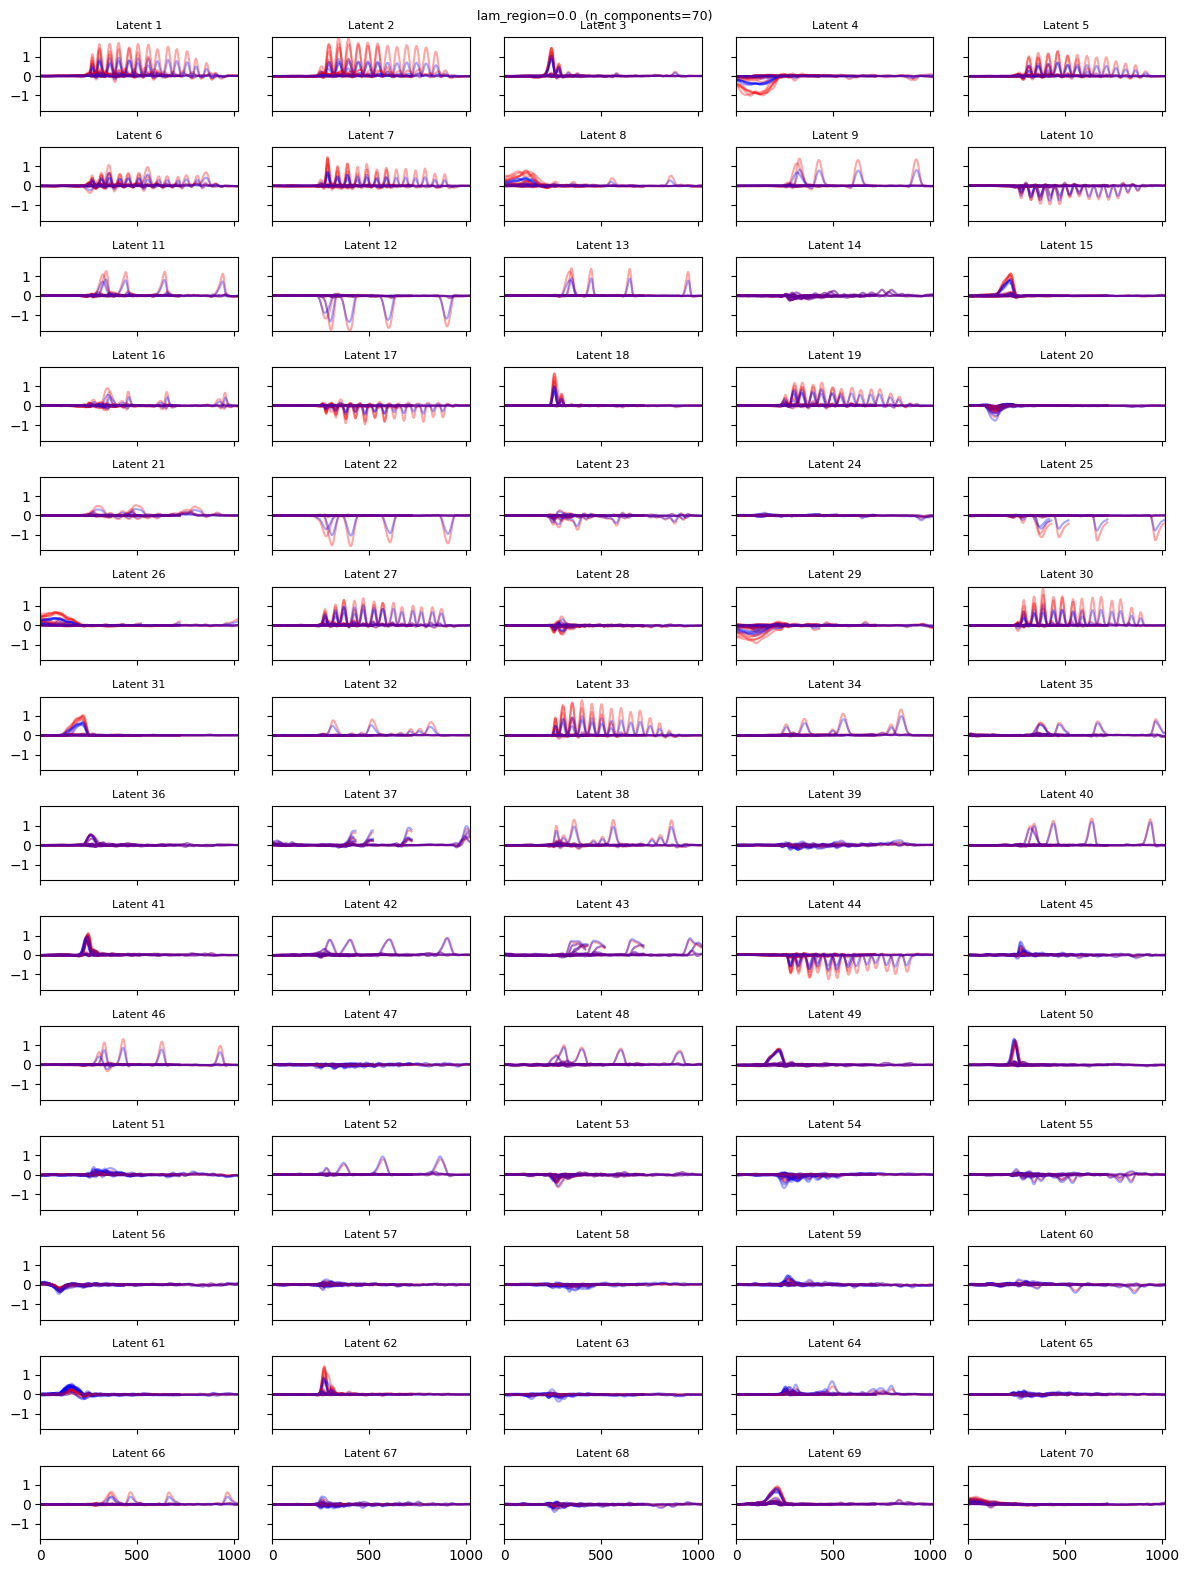


=== lam_region=0.1 ===

=== lam_region=0.3 ===
Initialized mSCA with lam_sparse=2.5, lam_orthog=0.0, lam_region=0.3
passed lam_sparse: 2.5
passed lam_orthog: 0.0
Using region-weights = {'M1': 0.7466287869447, 'SMA': 1.5136691790810932}
Using lam_sparse = 0.03124979428996457
Using lam_orthog = 0.0
Using lam_region = 145.13113314659532
Checkpoint training hyperparameters:
  lam_sparse  = 0.03124979428996457
  lam_orthog  = 0.0
  lam_region  = 145.13113314659532
  region_weights = {'M1': 0.7466287869447, 'SMA': 1.5136691790810932}


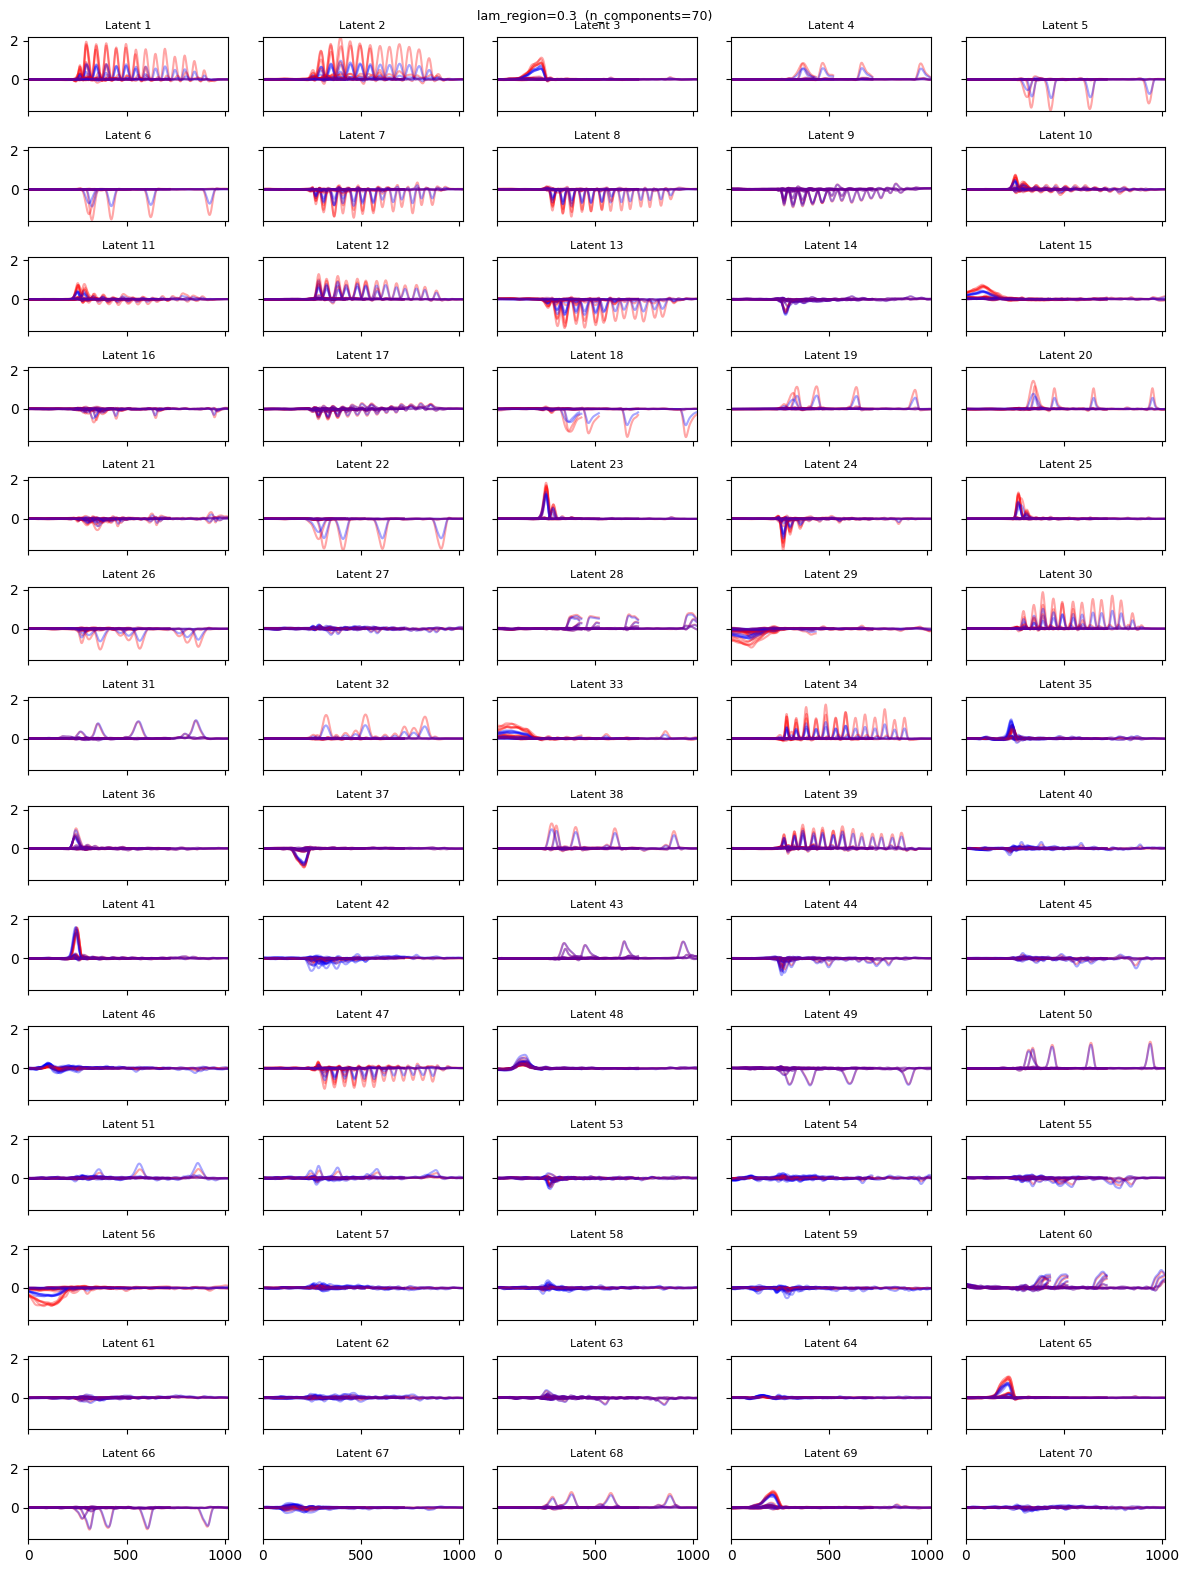

[2026-05-15 11:01:47,596] torch._dynamo.convert_frame: [WARNING] torch._dynamo hit config.cache_size_limit (8)
[2026-05-15 11:01:47,596] torch._dynamo.convert_frame: [WARNING]    function: 'forward' (/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/filters.py:124)
[2026-05-15 11:01:47,596] torch._dynamo.convert_frame: [WARNING]    last reason: ___guarded_code.valid
[2026-05-15 11:01:47,596] torch._dynamo.convert_frame: [WARNING] To log all recompilation reasons, use TORCH_LOGS="recompiles".
[2026-05-15 11:01:47,596] torch._dynamo.convert_frame: [WARNING] To diagnose recompilation issues, see https://pytorch.org/docs/master/compile/troubleshooting.html.



=== lam_region=0.5 ===

=== lam_region=0.8 ===

=== lam_region=1.0 ===

=== lam_region=1.2 ===

=== lam_region=1.5 ===

=== lam_region=1.8 ===

=== lam_region=2.0 ===

=== lam_region=2.3 ===

=== lam_region=2.5 ===

=== lam_region=2.6 ===
Initialized mSCA with lam_sparse=2.5, lam_orthog=0.0, lam_region=2.6
passed lam_sparse: 2.5
passed lam_orthog: 0.0
Using region-weights = {'M1': 0.7466287869447, 'SMA': 1.5136691790810932}
Using lam_sparse = 0.03124979428996457
Using lam_orthog = 0.0
Using lam_region = 1257.8031539371595
Checkpoint training hyperparameters:
  lam_sparse  = 0.03124979428996457
  lam_orthog  = 0.0
  lam_region  = 1257.8031539371595
  region_weights = {'M1': 0.7466287869447, 'SMA': 1.5136691790810932}


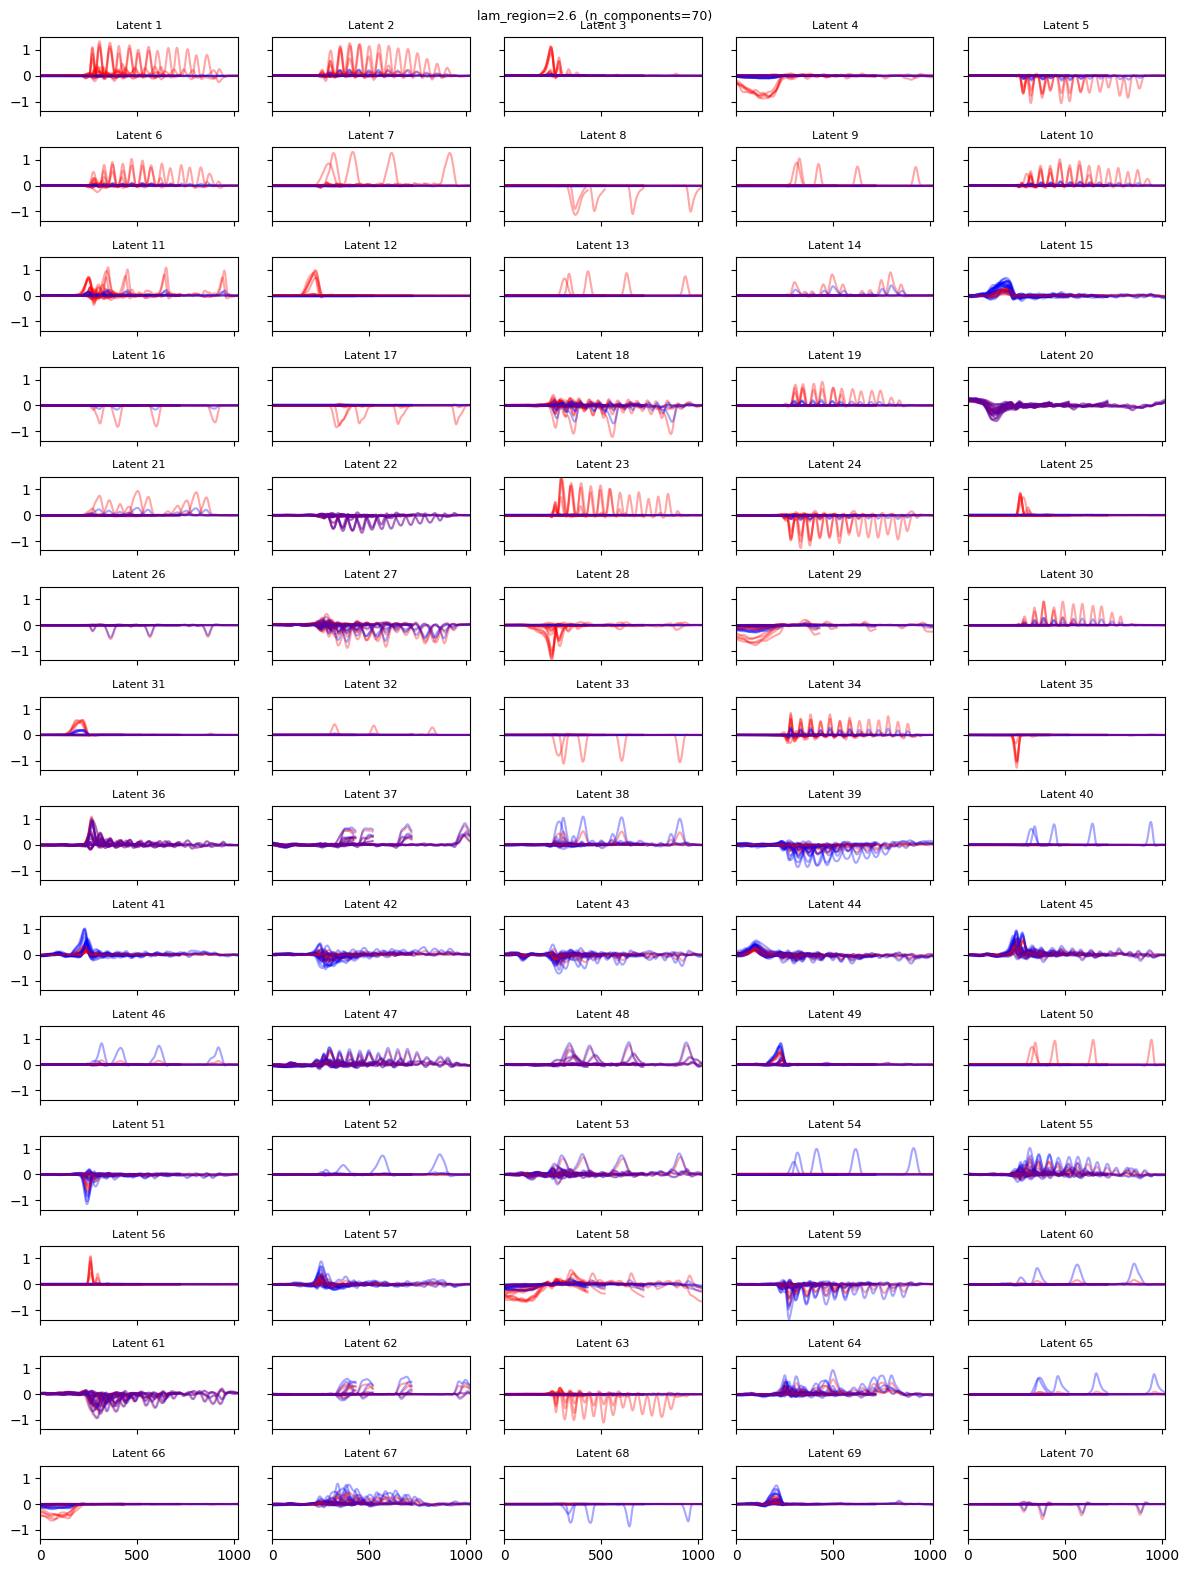

  [skip] missing fold 4

=== lam_region=2.8 ===

=== lam_region=3.0 ===


In [5]:
experiment_root = "./results/bi-cross-validation-Cousteau-nonlinear-nonlinear-lamsparse-2.5-components-70/"
n_components = 70  # FIXED: never overwrite this

train_idxs = torch.load(os.path.join(experiment_root, "n_train_splits.pt"), weights_only=False)
test_idxs  = torch.load(os.path.join(experiment_root, "n_test_splits.pt"),  weights_only=False)

k0 = list(train_idxs.keys())[0]
n_folds = len(train_idxs[k0])
print(f"Found {n_folds} neuron folds")

lam_dirs = []
for name in sorted(os.listdir(experiment_root)):
    path = os.path.join(experiment_root, name)
    if not (os.path.isdir(path) and name.startswith("lam_region_")):
        continue
    lam_str = name.replace("lam_region_", "").replace("p", ".")
    try:
        lam_dirs.append((float(lam_str), path))
    except ValueError:
        continue
lam_dirs.sort(key=lambda x: x[0])
print(f"Found {len(lam_dirs)} lam_region values: {[v for v, _ in lam_dirs]}")

results = {}

for lam_val, model_dir in lam_dirs:
    all_scores, m1_scores, sma_scores = [], [], []
    print(f"\n=== lam_region={lam_val} ===")
    if lam_val in (0.0, 0.3, 2.6):

        for fold_idx in range(n_folds):  # FIXED: use fold_idx instead of i
            model_path = os.path.join(model_dir, f"msca_split_{fold_idx}.pt")
            if not os.path.exists(model_path):
                print(f"  [skip] missing fold {fold_idx}")
                continue

            X_train_fold = {
                k: [trial[:, train_idxs[k][fold_idx]] for trial in v]
                for k, v in X.items()
            }
            X_val_fold = {
                k: [trial[:, test_idxs[k][fold_idx]] for trial in v]
                for k, v in X.items()
            }
            if fold_idx == 0:
                msca_model = mSCA(
                    n_components=n_components,
                    linear=False,
                    loss_func="Gaussian",
                    lam_sparse=2.5,
                    lam_orthog=0.0,
                    lam_region=lam_val,
                    decoder_type="nonlinear",
                    decoder_hidden_size=n_components,
                    decoder_activation="GeLU",
                    post_hoc_epoch=-1,
                    cd_rate=0.5,
                    cd_mode="both",
                    filter_len=41,
                    init="unique",
                    decoder_init_mode="pca",
                )
                msca_model.load(model_path, X_train_fold)

            
                Z = msca_model.transform(X_train_fold)
                n_plot =70      
                n_trials = min(20, len(Z['M1']), len(Z['SMA']))

                plot_vals = np.concatenate([
                    Z[r][j][:, :n_plot].ravel()
                    for r in ('M1', 'SMA') for j in range(n_trials)
                ])
                ymin, ymax = plot_vals.min(), plot_vals.max()
                max_t = max(max(Z['M1'][j].shape[0], Z['SMA'][j].shape[0]) for j in range(n_trials))

                fig, axs = plt.subplots(14, 5, figsize=(12, 16), sharex=True, sharey=True)
                for comp_idx in range(n_plot):  # FIXED: comp_idx, not i/fold_idx
                    ax = axs[comp_idx // 5, comp_idx % 5]
                    for j in range(n_trials):
                        ax.plot(Z['M1'][j][:, comp_idx], c='r', alpha=0.35)
                        ax.plot(Z['SMA'][j][:, comp_idx], c='b', alpha=0.35)
                    ax.set_xlim(0, max_t - 1)
                    ax.set_ylim(ymin, ymax)
                    ax.set_title(f'Latent {comp_idx + 1}', fontsize=8)

                plt.suptitle(f'lam_region={lam_val}  (n_components=70)', fontsize=9)
                plt.tight_layout()
                plt.show()

 

Found 5 neuron folds
Found 15 lam_region values: [0.0, 0.1, 0.3, 0.5, 0.8, 1.0, 1.2, 1.5, 1.8, 2.0, 2.3, 2.5, 2.6, 2.8, 3.0]

=== lam_region=0.0 ===
Initialized mSCA with lam_sparse=2.5, lam_orthog=0.0, lam_region=0.0
passed lam_sparse: 2.5
passed lam_orthog: 0.0
Using region-weights = {'M1': 0.7466287869447, 'SMA': 1.5136691790810932}
Using lam_sparse = 0.03124979428996457
Using lam_orthog = 0.0
Using lam_region = 0.0
Checkpoint training hyperparameters:
  lam_sparse  = 0.03124979428996457
  lam_orthog  = 0.0
  lam_region  = 0.0
  region_weights = {'M1': 0.7466287869447, 'SMA': 1.5136691790810932}
  fold 0: R²_all=0.7861  R²_M1=0.8055  R²_SMA=0.7511
Initialized mSCA with lam_sparse=2.5, lam_orthog=0.0, lam_region=0.0
passed lam_sparse: 2.5
passed lam_orthog: 0.0
Using region-weights = {'M1': 0.728905102689677, 'SMA': 1.5921556446861782}
Using lam_sparse = 0.03247957143006606
Using lam_orthog = 0.0
Using lam_region = 0.0
Checkpoint training hyperparameters:
  lam_sparse  = 0.0324795714

[2026-05-15 11:05:43,650] torch._dynamo.convert_frame: [WARNING] torch._dynamo hit config.cache_size_limit (8)
[2026-05-15 11:05:43,650] torch._dynamo.convert_frame: [WARNING]    function: '_gaussian_filter' (/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/filters.py:72)
[2026-05-15 11:05:43,650] torch._dynamo.convert_frame: [WARNING]    last reason: ___guarded_code.valid
[2026-05-15 11:05:43,650] torch._dynamo.convert_frame: [WARNING] To log all recompilation reasons, use TORCH_LOGS="recompiles".
[2026-05-15 11:05:43,650] torch._dynamo.convert_frame: [WARNING] To diagnose recompilation issues, see https://pytorch.org/docs/master/compile/troubleshooting.html.


  fold 2: R²_all=0.7927  R²_M1=0.8214  R²_SMA=0.7409
Initialized mSCA with lam_sparse=2.5, lam_orthog=0.0, lam_region=0.0
passed lam_sparse: 2.5
passed lam_orthog: 0.0
Using region-weights = {'M1': 0.7249360040331592, 'SMA': 1.6114272304897261}
Using lam_sparse = 0.032063722555482725
Using lam_orthog = 0.0
Using lam_region = 0.0
Checkpoint training hyperparameters:
  lam_sparse  = 0.032063722555482725
  lam_orthog  = 0.0
  lam_region  = 0.0
  region_weights = {'M1': 0.7249360040331592, 'SMA': 1.6114272304897261}
  fold 3: R²_all=0.7936  R²_M1=0.8374  R²_SMA=0.6866
Initialized mSCA with lam_sparse=2.5, lam_orthog=0.0, lam_region=0.0
passed lam_sparse: 2.5
passed lam_orthog: 0.0
Using region-weights = {'M1': 0.7711170825251707, 'SMA': 1.4221108373973068}
Using lam_sparse = 0.0309376605077267
Using lam_orthog = 0.0
Using lam_region = 0.0
Checkpoint training hyperparameters:
  lam_sparse  = 0.0309376605077267
  lam_orthog  = 0.0
  lam_region  = 0.0
  region_weights = {'M1': 0.7711170825251

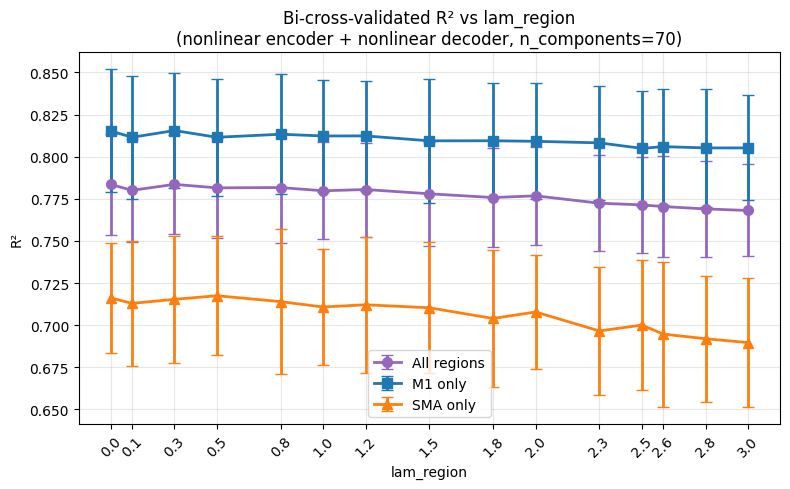


Summary:
  lam_region    R²_all     R²_M1    R²_SMA
         0.0    0.7836    0.8153    0.7162
         0.1    0.7800    0.8115    0.7129
         0.3    0.7836    0.8155    0.7153
         0.5    0.7815    0.8115    0.7175
         0.8    0.7817    0.8133    0.7140
         1.0    0.7797    0.8123    0.7108
         1.2    0.7805    0.8123    0.7121
         1.5    0.7780    0.8094    0.7103
         1.8    0.7757    0.8094    0.7040
         2.0    0.7768    0.8091    0.7078
         2.3    0.7724    0.8082    0.6966
         2.5    0.7714    0.8049    0.7001
         2.6    0.7704    0.8060    0.6947
         2.8    0.7690    0.8052    0.6919
         3.0    0.7681    0.8052    0.6896


In [6]:
experiment_root = "./results/bi-cross-validation-Cousteau-nonlinear-nonlinear-lamsparse-2.5-components-70/"
n_components = 70

# Load shared neuron split indices
train_idxs = torch.load(os.path.join(experiment_root, "n_train_splits.pt"), weights_only=False)
test_idxs  = torch.load(os.path.join(experiment_root, "n_test_splits.pt"),  weights_only=False)

k0 = list(train_idxs.keys())[0]
n_folds = len(train_idxs[k0])
print(f"Found {n_folds} neuron folds")

# Discover all lam_region subdirectories and sort numerically
lam_dirs = []
for name in sorted(os.listdir(experiment_root)):
    path = os.path.join(experiment_root, name)
    if not (os.path.isdir(path) and name.startswith("lam_region_")):
        continue
    lam_str = name.replace("lam_region_", "").replace("p", ".")
    try:
        lam_dirs.append((float(lam_str), path))
    except ValueError:
        continue
lam_dirs.sort(key=lambda x: x[0])
print(f"Found {len(lam_dirs)} lam_region values: {[v for v, _ in lam_dirs]}")

# Accumulate R² per lam_region
results = {}   # lam_value -> {"all": [...], "m1": [...], "sma": [...]}

for lam_val, model_dir in lam_dirs:
    all_scores, m1_scores, sma_scores = [], [], []
    print(f"\n=== lam_region={lam_val} ===")

    for i in range(n_folds):
        model_path = os.path.join(model_dir, f"msca_split_{i}.pt")
        if not os.path.exists(model_path):
            print(f"  [skip] missing fold {i}")
            continue

        # Build held-in / held-out neuron sets for this fold
        X_train_fold = {
            k: [trial[:, train_idxs[k][i]] for trial in v]
            for k, v in X.items()
        }
        X_val_fold = {
            k: [trial[:, test_idxs[k][i]] for trial in v]
            for k, v in X.items()
        }

        # Reconstruct model with the same config used during training
        msca_model = mSCA(
            n_components=n_components,
            linear=False,
            loss_func="Gaussian",
            lam_sparse=2.5,
            lam_orthog=0.0,
            lam_region=lam_val,
            decoder_type="nonlinear",
            decoder_hidden_size=n_components,
            decoder_activation="GeLU",
            post_hoc_epoch=-1,
            cd_rate=0.5,
            cd_mode="both",
            filter_len=41,
            init="unique",
            decoder_init_mode="pca",
        )
        msca_model.load(model_path, X_train_fold)

        # Evaluate: returns (performances_all, performances_m1, performances_sma)
        perf_all, perf_m1, perf_sma = evaluate_trial_average_MLP_region(
            msca_model, X_train_fold, X_val_fold, n_splits=5
        )
        all_scores.extend(perf_all)
        m1_scores.extend(perf_m1)
        sma_scores.extend(perf_sma)
        print(f"  fold {i}: R²_all={np.mean(perf_all):.4f}  "
              f"R²_M1={np.mean(perf_m1):.4f}  R²_SMA={np.mean(perf_sma):.4f}")

    if len(all_scores) == 0:
        print("  [warn] no valid scores, skipping.")
        continue

    results[lam_val] = {
        "all": np.array(all_scores, dtype=float),
        "m1":  np.array(m1_scores,  dtype=float),
        "sma": np.array(sma_scores,  dtype=float),
    }

print("\nEvaluation complete.")

# ── Plot ──────────────────────────────────────────────────────────────────────
lam_vals = sorted(results.keys())

mean_all = np.array([results[v]["all"].mean() for v in lam_vals])
std_all  = np.array([results[v]["all"].std()  for v in lam_vals])
mean_m1  = np.array([results[v]["m1"].mean()  for v in lam_vals])
std_m1   = np.array([results[v]["m1"].std()   for v in lam_vals])
mean_sma = np.array([results[v]["sma"].mean() for v in lam_vals])
std_sma  = np.array([results[v]["sma"].std()  for v in lam_vals])

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(lam_vals, mean_all, yerr=std_all,
            fmt="o-", color="tab:purple", linewidth=2, markersize=7, capsize=4,
            label="All regions")
ax.errorbar(lam_vals, mean_m1,  yerr=std_m1,
            fmt="s-", color="tab:blue",   linewidth=2, markersize=7, capsize=4,
            label="M1 only")
ax.errorbar(lam_vals, mean_sma, yerr=std_sma,
            fmt="^-", color="tab:orange", linewidth=2, markersize=7, capsize=4,
            label="SMA only")

ax.set_xlabel("lam_region")
ax.set_ylabel("R²")
ax.set_title("Bi-cross-validated R² vs lam_region\n"
             "(nonlinear encoder + nonlinear decoder, n_components=70)")
ax.set_xticks(lam_vals)
ax.tick_params(axis="x", rotation=45)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print("\nSummary:")
print(f"{'lam_region':>12}  {'R²_all':>8}  {'R²_M1':>8}  {'R²_SMA':>8}")
for v in lam_vals:
    print(f"{v:>12.1f}  {results[v]['all'].mean():>8.4f}  "
          f"{results[v]['m1'].mean():>8.4f}  {results[v]['sma'].mean():>8.4f}")


# 40 Linear


Found 5 neuron folds
Found 15 lam_region values: [0.0, 0.1, 0.3, 0.5, 0.8, 1.0, 1.2, 1.5, 1.8, 2.0, 2.3, 2.5, 2.6, 2.8, 3.0]

=== lam_region=0.0 ===
Initialized mSCA with lam_sparse=2.5, lam_orthog=0.0, lam_region=0.0
passed lam_sparse: 2.5
passed lam_orthog: 0.0
Using region-weights = {'M1': 0.7975064363288057, 'SMA': 1.3403179544112407}
Using lam_sparse = 0.08812463819255682
Using lam_orthog = 0.0
Using lam_region = 0.0
Checkpoint training hyperparameters:
  lam_sparse  = 0.08812463819255682
  lam_orthog  = 0.0
  lam_region  = 0.0
  region_weights = {'M1': 0.7975064363288057, 'SMA': 1.3403179544112407}
  fold 0: R²_all=0.7596  R²_M1=0.7770  R²_SMA=0.7278
Initialized mSCA with lam_sparse=2.5, lam_orthog=0.0, lam_region=0.0
passed lam_sparse: 2.5
passed lam_orthog: 0.0
Using region-weights = {'M1': 0.7748147412125208, 'SMA': 1.4097037476845866}
Using lam_sparse = 0.09067048718693743
Using lam_orthog = 0.0
Using lam_region = 0.0
Checkpoint training hyperparameters:
  lam_sparse  = 0.090

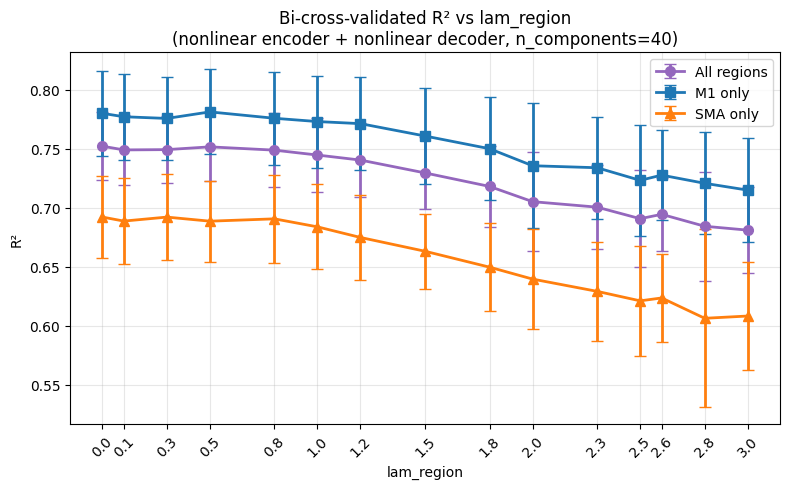


Summary:
  lam_region    R²_all     R²_M1    R²_SMA
         0.0    0.7521    0.7799    0.6921
         0.1    0.7489    0.7770    0.6887
         0.3    0.7492    0.7755    0.6921
         0.5    0.7515    0.7811    0.6886
         0.8    0.7487    0.7757    0.6906
         1.0    0.7446    0.7729    0.6838
         1.2    0.7403    0.7711    0.6748
         1.5    0.7294    0.7607    0.6632
         1.8    0.7180    0.7499    0.6497
         2.0    0.7051    0.7355    0.6396
         2.3    0.7005    0.7338    0.6292
         2.5    0.6907    0.7232    0.6212
         2.6    0.6944    0.7276    0.6236
         2.8    0.6843    0.7207    0.6064
         3.0    0.6810    0.7149    0.6083


In [6]:
experiment_root = "./results/bi-cross-validation-Cousteau-nonlinear-nonlinear-lamsparse-2.5-components-40/"
n_components = 40

# Load shared neuron split indices
train_idxs = torch.load(os.path.join(experiment_root, "n_train_splits.pt"), weights_only=False)
test_idxs  = torch.load(os.path.join(experiment_root, "n_test_splits.pt"),  weights_only=False)

k0 = list(train_idxs.keys())[0]
n_folds = len(train_idxs[k0])
print(f"Found {n_folds} neuron folds")

# Discover all lam_region subdirectories and sort numerically
lam_dirs = []
for name in sorted(os.listdir(experiment_root)):
    path = os.path.join(experiment_root, name)
    if not (os.path.isdir(path) and name.startswith("lam_region_")):
        continue
    lam_str = name.replace("lam_region_", "").replace("p", ".")
    try:
        lam_dirs.append((float(lam_str), path))
    except ValueError:
        continue
lam_dirs.sort(key=lambda x: x[0])
print(f"Found {len(lam_dirs)} lam_region values: {[v for v, _ in lam_dirs]}")

# Accumulate R² per lam_region
results = {}   # lam_value -> {"all": [...], "m1": [...], "sma": [...]}

for lam_val, model_dir in lam_dirs:
    all_scores, m1_scores, sma_scores = [], [], []
    print(f"\n=== lam_region={lam_val} ===")

    for i in range(n_folds):
        model_path = os.path.join(model_dir, f"msca_split_{i}.pt")
        if not os.path.exists(model_path):
            print(f"  [skip] missing fold {i}")
            continue

        # Build held-in / held-out neuron sets for this fold
        X_train_fold = {
            k: [trial[:, train_idxs[k][i]] for trial in v]
            for k, v in X.items()
        }
        X_val_fold = {
            k: [trial[:, test_idxs[k][i]] for trial in v]
            for k, v in X.items()
        }

        # Reconstruct model with the same config used during training
        msca_model = mSCA(
            n_components=n_components,
            linear=False,
            loss_func="Gaussian",
            lam_sparse=2.5,
            lam_orthog=0.0,
            lam_region=lam_val,
            decoder_type="nonlinear",
            decoder_hidden_size=n_components,
            decoder_activation="GeLU",
            post_hoc_epoch=-1,
            cd_rate=0.5,
            cd_mode="both",
            filter_len=41,
            init="unique",
            decoder_init_mode="pca",
        )
        msca_model.load(model_path, X_train_fold)

        # Evaluate: returns (performances_all, performances_m1, performances_sma)
        perf_all, perf_m1, perf_sma = evaluate_trial_average_Linear_region(
            msca_model, X_train_fold, X_val_fold, n_splits=5
        )
        all_scores.extend(perf_all)
        m1_scores.extend(perf_m1)
        sma_scores.extend(perf_sma)
        print(f"  fold {i}: R²_all={np.mean(perf_all):.4f}  "
              f"R²_M1={np.mean(perf_m1):.4f}  R²_SMA={np.mean(perf_sma):.4f}")

    if len(all_scores) == 0:
        print("  [warn] no valid scores, skipping.")
        continue

    results[lam_val] = {
        "all": np.array(all_scores, dtype=float),
        "m1":  np.array(m1_scores,  dtype=float),
        "sma": np.array(sma_scores,  dtype=float),
    }

print("\nEvaluation complete.")

# ── Plot ──────────────────────────────────────────────────────────────────────
lam_vals = sorted(results.keys())

mean_all = np.array([results[v]["all"].mean() for v in lam_vals])
std_all  = np.array([results[v]["all"].std()  for v in lam_vals])
mean_m1  = np.array([results[v]["m1"].mean()  for v in lam_vals])
std_m1   = np.array([results[v]["m1"].std()   for v in lam_vals])
mean_sma = np.array([results[v]["sma"].mean() for v in lam_vals])
std_sma  = np.array([results[v]["sma"].std()  for v in lam_vals])

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(lam_vals, mean_all, yerr=std_all,
            fmt="o-", color="tab:purple", linewidth=2, markersize=7, capsize=4,
            label="All regions")
ax.errorbar(lam_vals, mean_m1,  yerr=std_m1,
            fmt="s-", color="tab:blue",   linewidth=2, markersize=7, capsize=4,
            label="M1 only")
ax.errorbar(lam_vals, mean_sma, yerr=std_sma,
            fmt="^-", color="tab:orange", linewidth=2, markersize=7, capsize=4,
            label="SMA only")

ax.set_xlabel("lam_region")
ax.set_ylabel("R²")
ax.set_title("Bi-cross-validated R² vs lam_region\n"
             "(nonlinear encoder + nonlinear decoder, n_components=40)")
ax.set_xticks(lam_vals)
ax.tick_params(axis="x", rotation=45)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print("\nSummary:")
print(f"{'lam_region':>12}  {'R²_all':>8}  {'R²_M1':>8}  {'R²_SMA':>8}")
for v in lam_vals:
    print(f"{v:>12.1f}  {results[v]['all'].mean():>8.4f}  "
          f"{results[v]['m1'].mean():>8.4f}  {results[v]['sma'].mean():>8.4f}")


# 70 linear 

Found 5 neuron folds
Found 15 lam_region values: [0.0, 0.1, 0.3, 0.5, 0.8, 1.0, 1.2, 1.5, 1.8, 2.0, 2.3, 2.5, 2.6, 2.8, 3.0]

=== lam_region=0.0 ===
Initialized mSCA with lam_sparse=2.5, lam_orthog=0.0, lam_region=0.0
passed lam_sparse: 2.5
passed lam_orthog: 0.0
Using region-weights = {'M1': 0.7466287869447, 'SMA': 1.5136691790810932}
Using lam_sparse = 0.03124979428996457
Using lam_orthog = 0.0
Using lam_region = 0.0
Checkpoint training hyperparameters:
  lam_sparse  = 0.03124979428996457
  lam_orthog  = 0.0
  lam_region  = 0.0
  region_weights = {'M1': 0.7466287869447, 'SMA': 1.5136691790810932}
  fold 0: R²_all=0.7818  R²_M1=0.8013  R²_SMA=0.7460
Initialized mSCA with lam_sparse=2.5, lam_orthog=0.0, lam_region=0.0
passed lam_sparse: 2.5
passed lam_orthog: 0.0
Using region-weights = {'M1': 0.728905102689677, 'SMA': 1.5921556446861782}
Using lam_sparse = 0.03247957143006606
Using lam_orthog = 0.0
Using lam_region = 0.0
Checkpoint training hyperparameters:
  lam_sparse  = 0.0324795714

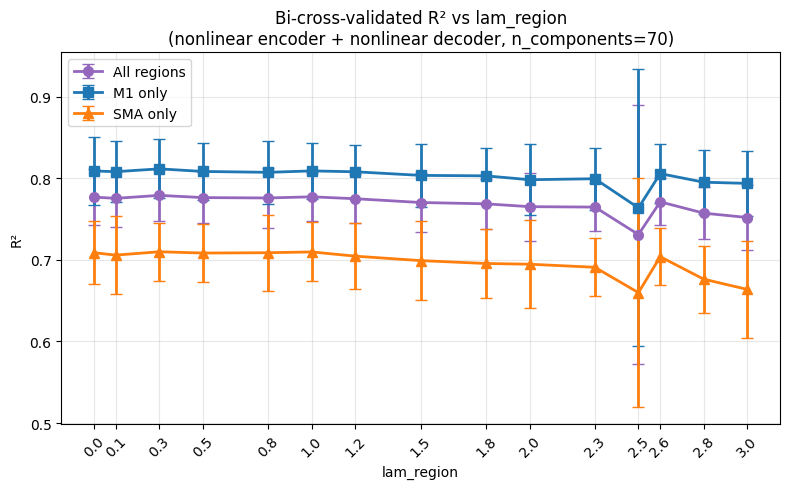


Summary:
  lam_region    R²_all     R²_M1    R²_SMA
         0.0    0.7769    0.8089    0.7088
         0.1    0.7754    0.8081    0.7058
         0.3    0.7791    0.8116    0.7099
         0.5    0.7763    0.8084    0.7084
         0.8    0.7759    0.8073    0.7088
         1.0    0.7773    0.8091    0.7097
         1.2    0.7749    0.8080    0.7045
         1.5    0.7703    0.8035    0.6991
         1.8    0.7687    0.8030    0.6956
         2.0    0.7652    0.7982    0.6947
         2.3    0.7647    0.7994    0.6909
         2.5    0.7311    0.7638    0.6598
         2.6    0.7711    0.8057    0.7039
         2.8    0.7573    0.7952    0.6763
         3.0    0.7519    0.7937    0.6638


In [8]:
experiment_root = "./results/bi-cross-validation-Cousteau-nonlinear-nonlinear-lamsparse-2.5-components-70/"
n_components = 70

# Load shared neuron split indices
train_idxs = torch.load(os.path.join(experiment_root, "n_train_splits.pt"), weights_only=False)
test_idxs  = torch.load(os.path.join(experiment_root, "n_test_splits.pt"),  weights_only=False)

k0 = list(train_idxs.keys())[0]
n_folds = len(train_idxs[k0])
print(f"Found {n_folds} neuron folds")

# Discover all lam_region subdirectories and sort numerically
lam_dirs = []
for name in sorted(os.listdir(experiment_root)):
    path = os.path.join(experiment_root, name)
    if not (os.path.isdir(path) and name.startswith("lam_region_")):
        continue
    lam_str = name.replace("lam_region_", "").replace("p", ".")
    try:
        lam_dirs.append((float(lam_str), path))
    except ValueError:
        continue
lam_dirs.sort(key=lambda x: x[0])
print(f"Found {len(lam_dirs)} lam_region values: {[v for v, _ in lam_dirs]}")

# Accumulate R² per lam_region
results = {}   # lam_value -> {"all": [...], "m1": [...], "sma": [...]}

for lam_val, model_dir in lam_dirs:
    all_scores, m1_scores, sma_scores = [], [], []
    print(f"\n=== lam_region={lam_val} ===")

    for i in range(n_folds):
        model_path = os.path.join(model_dir, f"msca_split_{i}.pt")
        if not os.path.exists(model_path):
            print(f"  [skip] missing fold {i}")
            continue

        # Build held-in / held-out neuron sets for this fold
        X_train_fold = {
            k: [trial[:, train_idxs[k][i]] for trial in v]
            for k, v in X.items()
        }
        X_val_fold = {
            k: [trial[:, test_idxs[k][i]] for trial in v]
            for k, v in X.items()
        }

        # Reconstruct model with the same config used during training
        msca_model = mSCA(
            n_components=n_components,
            linear=False,
            loss_func="Gaussian",
            lam_sparse=2.5,
            lam_orthog=0.0,
            lam_region=lam_val,
            decoder_type="nonlinear",
            decoder_hidden_size=n_components,
            decoder_activation="GeLU",
            post_hoc_epoch=-1,
            cd_rate=0.5,
            cd_mode="both",
            filter_len=41,
            init="unique",
            decoder_init_mode="pca",
        )
        msca_model.load(model_path, X_train_fold)

        # Evaluate: returns (performances_all, performances_m1, performances_sma)
        perf_all, perf_m1, perf_sma = evaluate_trial_average_Linear_region(
            msca_model, X_train_fold, X_val_fold, n_splits=5
        )
        all_scores.extend(perf_all)
        m1_scores.extend(perf_m1)
        sma_scores.extend(perf_sma)
        print(f"  fold {i}: R²_all={np.mean(perf_all):.4f}  "
              f"R²_M1={np.mean(perf_m1):.4f}  R²_SMA={np.mean(perf_sma):.4f}")

    if len(all_scores) == 0:
        print("  [warn] no valid scores, skipping.")
        continue

    results[lam_val] = {
        "all": np.array(all_scores, dtype=float),
        "m1":  np.array(m1_scores,  dtype=float),
        "sma": np.array(sma_scores,  dtype=float),
    }

print("\nEvaluation complete.")

# ── Plot ──────────────────────────────────────────────────────────────────────
lam_vals = sorted(results.keys())

mean_all = np.array([results[v]["all"].mean() for v in lam_vals])
std_all  = np.array([results[v]["all"].std()  for v in lam_vals])
mean_m1  = np.array([results[v]["m1"].mean()  for v in lam_vals])
std_m1   = np.array([results[v]["m1"].std()   for v in lam_vals])
mean_sma = np.array([results[v]["sma"].mean() for v in lam_vals])
std_sma  = np.array([results[v]["sma"].std()  for v in lam_vals])

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(lam_vals, mean_all, yerr=std_all,
            fmt="o-", color="tab:purple", linewidth=2, markersize=7, capsize=4,
            label="All regions")
ax.errorbar(lam_vals, mean_m1,  yerr=std_m1,
            fmt="s-", color="tab:blue",   linewidth=2, markersize=7, capsize=4,
            label="M1 only")
ax.errorbar(lam_vals, mean_sma, yerr=std_sma,
            fmt="^-", color="tab:orange", linewidth=2, markersize=7, capsize=4,
            label="SMA only")

ax.set_xlabel("lam_region")
ax.set_ylabel("R²")
ax.set_title("Bi-cross-validated R² vs lam_region\n"
             "(nonlinear encoder + nonlinear decoder, n_components=70)")
ax.set_xticks(lam_vals)
ax.tick_params(axis="x", rotation=45)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print("\nSummary:")
print(f"{'lam_region':>12}  {'R²_all':>8}  {'R²_M1':>8}  {'R²_SMA':>8}")
for v in lam_vals:
    print(f"{v:>12.1f}  {results[v]['all'].mean():>8.4f}  "
          f"{results[v]['m1'].mean():>8.4f}  {results[v]['sma'].mean():>8.4f}")
